/Users/jiwoongpark/anaconda3/envs/Eyetracking/lib/python3.11/site-packages/mocet/simulation.py:113: RuntimeWarning: invalid value encountered in multiply
  intersection = O + distance * ray_direction


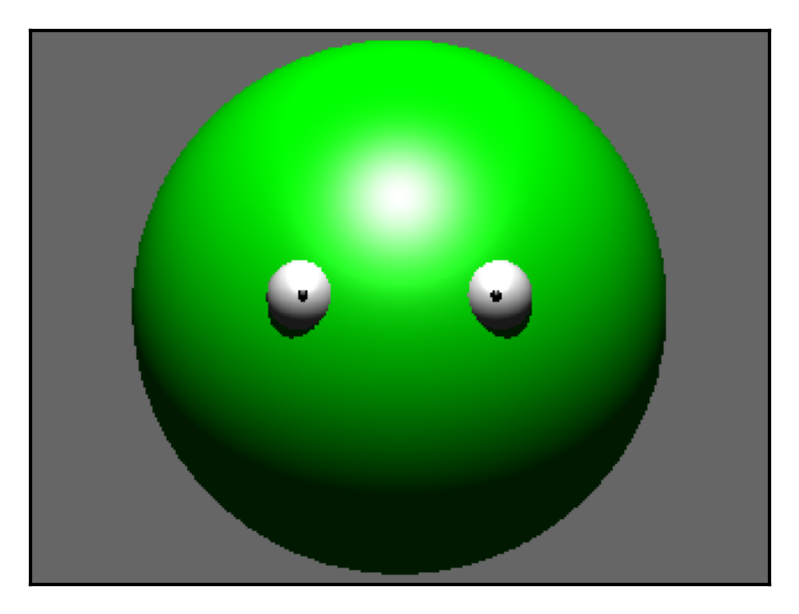

In [3]:
# just for simulation figures
import seaborn as sns
import mocet
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

plt.style.use('default')
screen = mocet.simulation.Screen()
gaze_target = screen.get_target(np.array([800,500]))

head = mocet.simulation.Head()
head.set_gaze(gaze=gaze_target)
head.add_eyeball_left()
head.add_eyeball_right()

scene = mocet.simulation.Scene(width=128*8, height=96*8, objects=head.objects)
scene.add_camera(camera_position=(0, 1, 0), 
                 camera_direction=(0,-1,0))
scene.add_light(light_position=(0, 1.0, 1.0), light_color=(1, 1, 1))
scene.render()

image = np.flip(scene.image, axis=1)
image = 255.0 * image
image = image.astype(np.uint8)
im = Image.fromarray(image).resize((320, 240), Image.NEAREST)
        
plt.figure(dpi=300, figsize=(3.2, 2.4))
plt.imshow(im)
colors = sns.color_palette("Reds", 12)
plt.xticks([])
plt.yticks([])
plt.show()


/Users/jiwoongpark/anaconda3/envs/Eyetracking/lib/python3.11/site-packages/mocet/simulation.py:113: RuntimeWarning: invalid value encountered in multiply
  intersection = O + distance * ray_direction


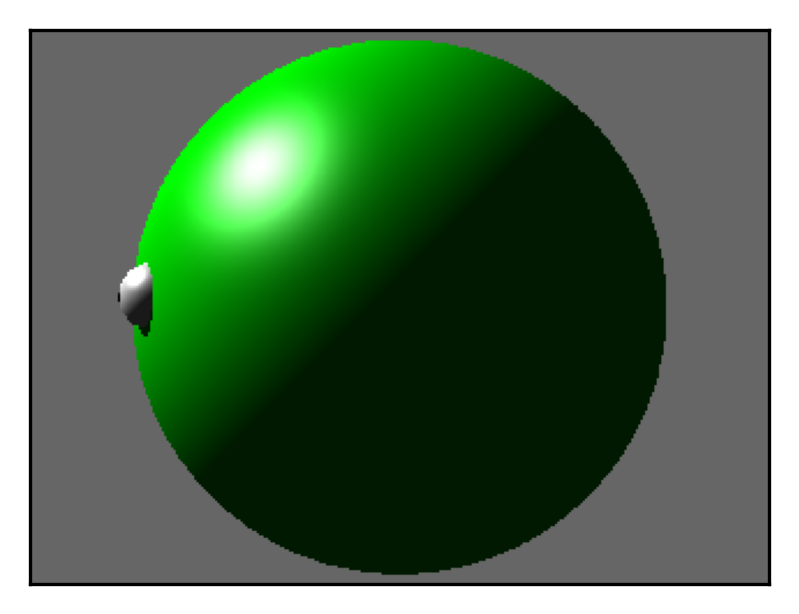

In [4]:
# just for simulation figures
import seaborn as sns
import mocet
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

plt.style.use('default')
screen = mocet.simulation.Screen()
gaze_target = screen.get_target(np.array([800,500]))

head = mocet.simulation.Head()
head.set_gaze(gaze=gaze_target)
head.add_eyeball_left()
head.add_eyeball_right()

scene = mocet.simulation.Scene(width=128*8, height=96*8, objects=head.objects)
scene.add_camera(camera_position=(1, 0, 0), 
                 camera_direction=(-1,0,0))
scene.add_light(light_position=(0, 1.0, 1.0), light_color=(1, 1, 1))
scene.render()

image = np.flip(scene.image, axis=1)
image = 255.0 * image
image = image.astype(np.uint8)
im = Image.fromarray(image).resize((320, 240), Image.NEAREST)
        
plt.figure(dpi=300, figsize=(3.2, 2.4))
plt.imshow(im)
colors = sns.color_palette("Reds", 12)
plt.xticks([])
plt.yticks([])
plt.show()


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

x_direction_range = np.linspace(-np.deg2rad(5), np.deg2rad(5), 9)
z_direction_range = np.linspace(-np.deg2rad(5), np.deg2rad(5), 9)
orientation_range = np.arange(-90, 91, 5)
depth_range = [0.14,0.15, 0.16, 0.17, 0.18, 0.19, 0.20, 0.21, 0.22, 0.23, 0.24, 0.25]
total_count = len(x_direction_range)*len(z_direction_range)*len(depth_range)*len(orientation_range)*12
print(total_count, total_count/12)

basis_log_fname = f'data/basis_log.csv'
basis_log = pd.read_csv(basis_log_fname)
basis_pupill_data = basis_log[["center_x","center_y","confidence"]]
basis_pupill_data = basis_pupill_data.to_numpy()

basis = []
basis_params = []
idx = 0
for x, x_d in enumerate(x_direction_range):
    for z, z_d in enumerate(z_direction_range):
        for depth in depth_range:
            for d, deg in enumerate(orientation_range):
                tmp_basis = np.zeros((12,2))
                for t in range(12):
                    tmp_basis[t,:] = basis_pupill_data[idx, :2]
                    idx += 1
                if np.any(tmp_basis == -1):
                    pass
                else:
                    basis.append(tmp_basis)
                    basis_params.append([x_d, z_d, depth, deg])

basis = np.array(basis)
np.save("data/basis.npy", basis)

basis_params = np.array(basis_params)
np.save("data/basis_params.npy", basis_params)

431568 35964.0


In [6]:
import pickle
import mocet
import os

testable_data = pickle.load(open('../minecraft_testable_data_extend.pkl', 'rb'))

subject_pool = {
                'sub-003':{'ses-07R':([1,2,3,4,5], False),
                           'ses-13R':([1,2,4,5,6], False)},
                'sub-004':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-005':{'ses-07':([1,2,3,4,5,6], True)},
                'sub-006':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-008':{'ses-07R':([2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-009':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,5,6], False)},
                'sub-010':{'ses-07':([1,2,3,4,5], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-011':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-012':{'ses-07':([1,2,4,5,6], False)},
                'sub-013':{'ses-07':([1,2,3,4], False)},
                'sub-014':{'ses-07':([2,3,4,5,6], False)},
                'sub-015':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-016':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-017':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5], False)},
                'sub-018':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-020':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-021':{'ses-07':([1,2,4,5,6], False),
                           'ses-13':([1,2,4,5,6], False)},
                'sub-JJY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-KMY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-PJW':{'ses-07':([1,2,3,4,6], True)},
                'sub-PBJ':{'ses-07':([1,2,3,4,5], False)}
                }


history_onset = {'sub-005': [28.66, 29.32, 28.12, 33.7, 36.1, 27.46],
                 'sub-PJW': [35, 30.8, 28.66, 26.58, None, 27.42]}
task_duration = 816

calibration_onsets = [1, 494]
calibration_points = [24, 12]
interval = 1.6 
calibration_offset_start = 0.5
calibration_offset_end = -0.5
t_cal = 0

optimized_camera_parameters = []
for key in testable_data.keys():
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])

    root = f'../../_DATA/{subject}/{session}'
    log_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_log.csv'
    data_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_dat.txt'
    confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'

    runs, history_loss = subject_pool[subject][session]
    if history_loss: 
        start = history_onset[subject][r-1]
    else:
        history_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_his.txt'
        start, _, _ = mocet.utils.get_avotec_history(history_fname)

    # log, data, confound, start
    pupil_data, pupil_timestamps, pupil_confidence, pupil_diameter = mocet.utils.clean_avotec_data(log_fname,
                                                                                            data_fname,
                                                                                            start=start,
                                                                                            duration=task_duration)
    offset = calibration_onsets[t_cal]
    calibration_pupils = []
    for i in np.arange(calibration_points[t_cal]):
        start = (offset+i)*interval + calibration_offset_start
        end = (offset+i+1)*interval + calibration_offset_end
        log_effective = np.logical_and(pupil_timestamps >= start*1000, pupil_timestamps < end*1000)
        calibration_pupils.append([np.nanmean(pupil_data[log_effective,0]),
                                  np.nanmean(pupil_data[log_effective,1])])
    calibration_pupils = np.array(calibration_pupils).reshape(2,12,2).mean(axis=0)
    
    basis_similarity = []
    for i in range(len(basis)):
        basis_similarity.append(np.mean(np.sqrt(np.sum((basis[i] - calibration_pupils)**2, axis=-1))))
    basis_idx = np.argmin(basis_similarity)
    print(subject, session, task, run, r, basis_idx)
    
    optimized_camera_parameters.append(basis_params[basis_idx])
optimized_camera_parameters = np.array(optimized_camera_parameters)

sub-003 ses-07R task-mcHERDING run-1 1 10977
sub-003 ses-07R task-mcHERDING run-2 2 10792
sub-003 ses-07R task-mcHERDING run-3 3 7188
sub-003 ses-07R task-mcHERDING run-4 4 7623
sub-003 ses-13R task-mcHERDING run-1 1 17187
sub-003 ses-13R task-mcHERDING run-2 2 16785
sub-003 ses-13R task-mcHERDING run-4 4 16744
sub-003 ses-13R task-mcHERDING run-5 5 16750
sub-004 ses-07R task-mcHERDING run-1 1 10491
sub-004 ses-07R task-mcHERDING run-2 2 10825
sub-004 ses-07R task-mcHERDING run-3 3 11267
sub-004 ses-07R task-mcHERDING run-4 4 11230
sub-004 ses-07R task-mcHERDING run-5 5 11230
sub-004 ses-07R task-mcHERDING run-6 6 10863
sub-004 ses-13 task-mcHERDING run-1 1 24080
sub-004 ses-13 task-mcHERDING run-2 2 24412
sub-004 ses-13 task-mcHERDING run-3 3 18334
sub-004 ses-13 task-mcHERDING run-4 4 21297
sub-004 ses-13 task-mcHERDING run-5 5 24411
sub-004 ses-13 task-mcHERDING run-6 6 24561
sub-005 ses-07 task-mcHERDING run-1 1 10493
sub-005 ses-07 task-mcHERDING run-2 2 10451
sub-005 ses-07 task-

In [7]:
print(np.mean(optimized_camera_parameters, axis=0))

[-0.01043403  0.01639634  0.22627329 -1.08695652]


In [13]:
np.rad2deg(np.arctan2(0.01639634, 1))

0.9393569086025884